# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 16:53:10,721] A new study created in memory with name: no-name-0ebccef3-9640-4ceb-8ba8-d169a9ceec8c
[I 2026-04-09 16:53:11,045] Trial 0 finished with value: 0.7480916030534351 and parameters: {'n_estimators': 287, 'max_depth': 13}. Best is trial 0 with value: 0.7480916030534351.
[I 2026-04-09 16:53:11,269] Trial 1 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 245, 'max_depth': 6}. Best is trial 0 with value: 0.7480916030534351.
[I 2026-04-09 16:53:11,453] Trial 2 finished with value: 0.6896551724137931 and parameters: {'n_estimators': 218, 'max_depth': 4}. Best is trial 0 with value: 0.7480916030534351.
[I 2026-04-09 16:53:11,603] Trial 3 finished with value: 0.7142857142857143 and parameters: {'n_estimators': 149, 'max_depth': 7}. Best is trial 0 with value: 0.7480916030534351.
[I 2026-04-09 16:53:11,722] Trial 4 finished with value: 0.6902654867256637 and parameters: {'n_estimators': 143, 'max_depth': 3}. Best is trial 0 with value: 0.74809160

RF F1: 0.7480916030534351
LR F1: 0.71875
SVM F1: 0.7166666666666667
KNN F1: 0.7555555555555555


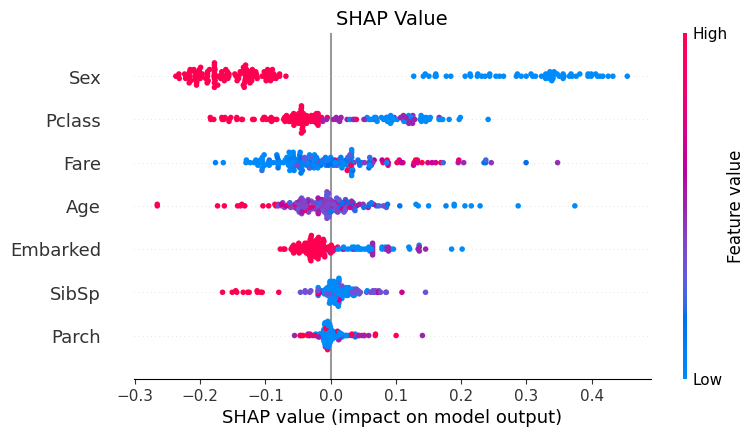

Stacking F1: 0.7559055118110236


In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv("titanic.csv")

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")

# 결측치 처리
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop("Survived", axis=1)
y = df["Survived"]

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)


def objective_lr(trial):
    params = {"C": trial.suggest_float("C", 0.01, 10)}
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)


def objective_svm(trial):
    params = {
        "C": trial.suggest_float("C", 0.1, 10),
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf"]),
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)


def objective_knn(trial):
    params = {"n_neighbors": trial.suggest_int("n_neighbors", 3, 15)}
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)


# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction="maximize")
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [("RF", rf), ("LR", lr), ("SVM", svm), ("KNN", knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values,  # shape value 반환
    X_valid,  # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns,  # 컬럼리스트
    plot_type="dot",
    show=False,
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [("rf", rf), ("svm", svm), ("knn", knn)]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators=est_model_list,  # 전방모델
    final_estimator=LogisticRegression(),  # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [3]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. 데이터 로드
df = pd.read_csv("Bank Customer Churn Prediction.csv")

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=["customer_id"], errors="ignore")

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df["country"] = le_country.fit_transform(df["country"])
df["gender"] = le_gender.fit_transform(df["gender"])

# split
train_df, valid_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["churn"]
)

# PyCaret으로 F1 상위 4개 모델 확인 (재현성 확보)
try:
    from pycaret.classification import setup, compare_models, pull

    clf = setup(
        data=train_df,  # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
        target="churn",
        session_id=42,
        verbose=False,
    )

    top4_models = compare_models(sort="F1", n_select=4)
    top4_table = pull().copy()
    print("PyCaret F1 상위 4개 모델")
    print(top4_table[["Model", "F1"]].head(4))
except Exception as e:
    print("PyCaret 실행 실패로 수동 모델 리스트를 사용합니다.")
    print("오류:", e)
    top4_models = None
    top4_table = None

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0450
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.1230
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1120
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,0.7400
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1010
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0270
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.0710
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0110
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0080
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0090


PyCaret F1 상위 4개 모델
                                    Model      F1
ada                  Ada Boost Classifier  0.5748
lightgbm  Light Gradient Boosting Machine  0.5726
gbc          Gradient Boosting Classifier  0.5708
catboost              CatBoost Classifier  0.5708


In [4]:
import warnings
import matplotlib.pyplot as plt

warnings.simplefilter("once")  # 중요한 경고는 1회는 보이도록 유지

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드
df = pd.read_csv(
    "Bank Customer Churn Prediction.csv"
)  # CSV 파일을 데이터프레임으로 불러오기
df.head()  # 상위 5행으로 데이터 구조 확인

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB

결측치 개수:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
produc

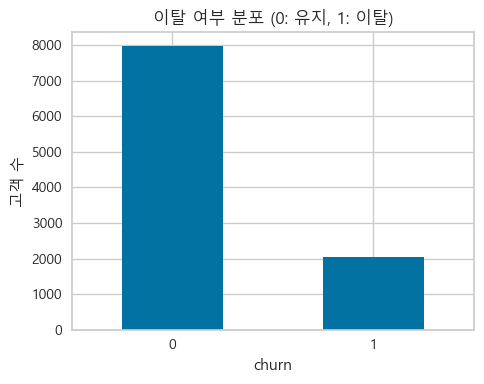

<Figure size 700x400 with 0 Axes>

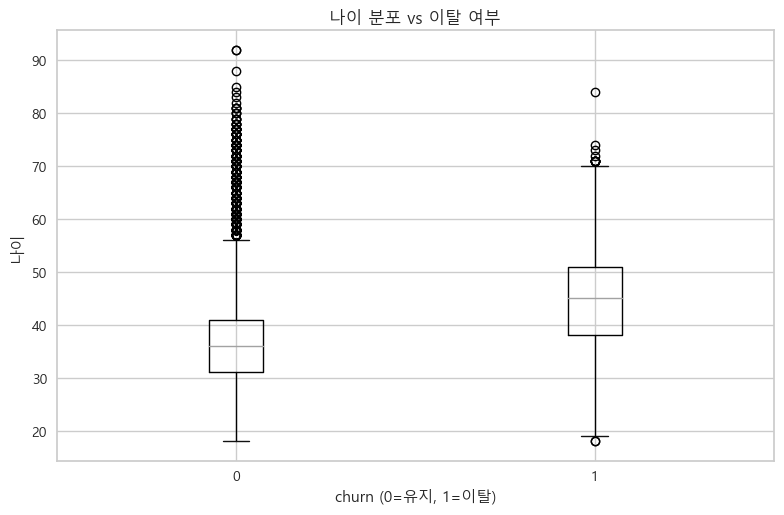

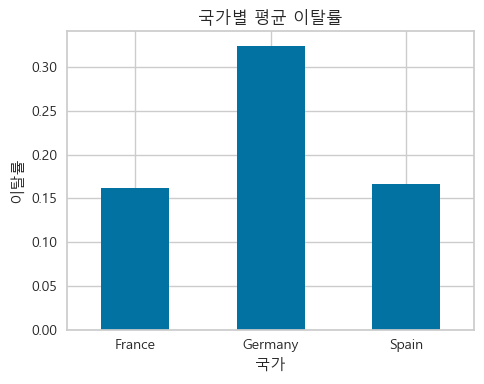

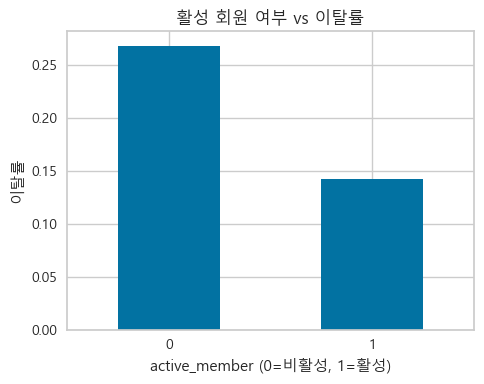

<Figure size 700x400 with 0 Axes>

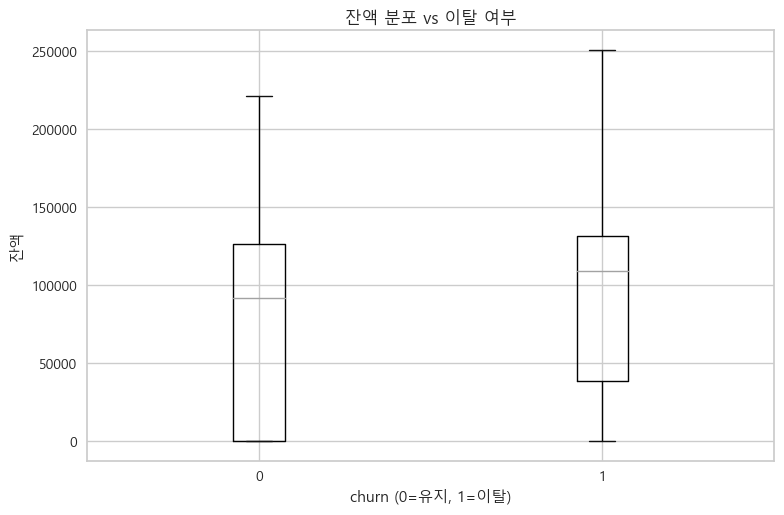

In [ ]:
df.info()  # 컬럼별 데이터 타입과 결측치 개수 확인
print("\n결측치 개수:\n", df.isnull().sum())  # 컬럼별 결측치 수 확인

# EDA
# 타겟(churn)과 각 피처 간 관계를 시각으로 파악해 전처리 방향과 모델 선정의 근거를 마련하기 위함

# 1. 이탈 여부 분포 확인 (클래스 불균형 파악)
churn_counts = df["churn"].value_counts()  # 이탈(1) vs 유지(0) 고객 수 집계
plt.figure(figsize=(5, 4))
churn_counts.plot(kind="bar")  # 막대 그래프로 분포 시각화
plt.title("이탈 여부 분포 (0: 유지, 1: 이탈)")
plt.xlabel("churn")
plt.ylabel("고객 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# → 약 20%만 이탈. 클래스 불균형 존재 → 모델이 다수 클래스에 편향될 위험이 크므로, 소수 클래스에 대한 예측력을 엄밀히 측정할 수 있는 F1-Score를 평가지표로 도입

# 2. 나이 vs 이탈 여부
plt.figure(figsize=(7, 4))
df.boxplot(column="age", by="churn")  # 이탈 여부별 나이 분포를 박스플롯으로 비교
plt.title("나이 분포 vs 이탈 여부")
plt.suptitle("")
plt.xlabel("churn (0=유지, 1=이탈)")
plt.ylabel("나이")
plt.tight_layout()
plt.show()
# → 이탈 고객의 나이 중앙값이 유지 고객보다 높음 → 나이가 중요한 예측 변수

# 3. 국가 vs 평균 이탈률
country_churn = df.groupby("country")["churn"].mean()  # 국가별 이탈률 평균 계산
plt.figure(figsize=(5, 4))
country_churn.plot(kind="bar")  # 국가별 이탈률 막대 그래프
plt.title("국가별 평균 이탈률")
plt.xlabel("국가")
plt.ylabel("이탈률")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# → Germany 이탈률이 France/Spain의 약 2배 → 국가가 이탈에 유의미한 영향을 줌

# 4. 활성 회원 여부 vs 이탈률
active_churn = df.groupby("active_member")["churn"].mean()  # 활성 여부별 이탈률 평균
plt.figure(figsize=(5, 4))
active_churn.plot(kind="bar")
plt.title("활성 회원 여부 vs 이탈률")
plt.xlabel("active_member (0=비활성, 1=활성)")
plt.ylabel("이탈률")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# → 비활성 회원 이탈률이 활성 회원 이탈률에 비해 약 2배 높음 → active_member는 핵심 예측 피처로 판단

# 5. 잔액 vs 이탈 여부
plt.figure(figsize=(7, 4))
df.boxplot(column="balance", by="churn")  # 이탈 여부별 잔액 분포 박스플롯
plt.title("잔액 분포 vs 이탈 여부")
plt.suptitle("")
plt.xlabel("churn (0=유지, 1=이탈)")
plt.ylabel("잔액")
plt.tight_layout()
plt.show()
# → 이탈 고객의 잔액 중앙값이 더 높음 → 고잔액 고객이 오히려 이탈하는 역설적 패턴 발견

# EDA 결과, 고객 이탈 예측 모델링을 위한 핵심 인사이트와 전처리 방향을 다음과 같이 도출했습니다.
# 1. 타겟 변수의 불균형 및 평가 지표 선정: 타겟 변수인 이탈 여부 분포 확인 결과, 이탈 고객 비율이 약 20%로 뚜렷한 클래스 불균형이 관찰되었습니다.
#    이는 학습 모델이 다수 클래스에 편향될 위험을 시사하므로, 모델의 성능 평가는 단순 정확도가 아닌 소수 클래스 예측력을 엄밀히 측정할 수 있는 F1-Score를 도입하는 것이 타당합니다.
# 2. 인구통계학적 및 지리적 특성의 영향력: 이탈 고객의 연령대 중앙값이 유지 고객보다 높게 나타나, 나이가 이탈을 설명하는 주요 변수임을 확인했습니다.
#    또한 국가별 분석에서 독일의 이탈률이 프랑스 및 스페인 대비 약 2배가량 높게 나타나, 지리적 특성 역시 모델의 중요한 피처로 작용할 것입니다.
# 3. 고객 행동 및 자산 특성의 역설적 패턴: 비활성 회원의 이탈률이 활성 회원보다 2배가량 높아 서비스 참여도가 이탈과 직결됨을 알 수 있습니다.
#    특히, 이탈 고객의 계좌 잔액 중앙값이 유지 고객보다 높게 형성되는 역설적인 패턴이 발견되었습니다. 이는 고잔액 고객들이 타행의 더 나은 혜택을 찾아 이탈할 가능성을 암시합니다.

In [ ]:
# 전처리 및 판단 근거
# 1. customer_id 제거: 고유 식별자로 예측력이 없어 모델 학습에 불필요
# 2. country/gender 인코딩: 범주형(문자열) → 수치형으로 변환 (모델이 처리 가능하도록)
# 3. 결측치 없음 (df.isnull().sum() 확인) → 별도 결측치 처리 불필요
# 4. credit_card, active_member는 이미 0/1 이진형 → 추가 인코딩 불필요
# 5. StandardScaler: 피처 간 스케일 차이를 제거 → 거리 기반/부스팅 모델 모두 안정적 학습

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df2 = pd.read_csv("Bank Customer Churn Prediction.csv")
df2 = df2.drop(columns=["customer_id"])  # 식별자 제거

X = df2.drop(columns=["churn"])  # 피처 (DataFrame 유지 → SHAP 컬럼명 활용)
y = df2["churn"]  # 타겟

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# split 이후 train 데이터로만 fit → 데이터 누수 방지
le_country = LabelEncoder()
le_gender = LabelEncoder()
X_train["country"] = le_country.fit_transform(X_train["country"])
X_valid["country"] = le_country.transform(X_valid["country"])  # transform만 적용
X_train["gender"] = le_gender.fit_transform(X_train["gender"])
X_valid["gender"] = le_gender.transform(X_valid["gender"])  # transform만 적용

ss = StandardScaler()
X_train = ss.fit_transform(X_train)  # 학습 데이터로 fit + transform
X_valid = ss.transform(X_valid)  # fit 금지 - 데이터 누수 방지 (transform만 적용)

In [7]:
# Feature Selection 근거 + 모델 선정 기준
# - customer_id 제거: 고유 식별자, 예측력 없음
# - 나머지 10개 피처 전부 사용:
#   age: 나이 많을수록 이탈 높음 (EDA에서 확인)
#   active_member: 비활성 시 이탈 높음 (EDA에서 확인)
#   country: 독일 이탈률 2배 (EDA에서 확인)
#   balance: 고잔액 이탈 패턴 (EDA에서 확인)
#   credit_score, tenure, products_number, credit_card, gender, estimated_salary:
#   금융 도메인에서 고객 이탈 예측에 일반적으로 유의미한 변수로 알려져 있음
# → 금융 도메인 근거 + EDA 결과로 모든 피처가 타당하여 전체 사용

# [ML 모델 선정 기준]
# - 직전 PyCaret 결과에서 F1 상위권 모델군을 확인
# - 본 셀은 CatBoost / GradientBoosting / XGBoost / AdaBoost를 동일 지표(F1)로 재검증
# - 고정 점수 하드코딩 대신 아래 실제 출력값을 근거로 제출

import optuna
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

if "top4_table" in globals() and top4_table is not None:
    print("직전 PyCaret 상위 모델 요약")
    print(top4_table[["Model", "F1"]].head(4))

# Optuna: F1을 최대화하도록 각 모델의 최적 하이퍼파라미터를 자동 탐색


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 500),  # 부스팅 반복 횟수
        "depth": trial.suggest_int("depth", 3, 10),  # 트리 깊이
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),  # 학습률
    }
    model = CatBoostClassifier(
        **params, random_state=42, verbose=0
    )  # CatBoost 모델 선언
    model.fit(X_train, y_train)  # 학습 데이터로 학습
    pred = model.predict(X_valid)  # 검증 데이터로 예측
    return f1_score(y_valid, pred)  # F1 score 반환


def objective_gb(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 300
        ),  # 트리 개수(= 부스팅 반복 횟수)(= 부스팅 반복 횟수)
        "max_depth": trial.suggest_int("max_depth", 3, 7),  # 개별 트리 깊이
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3
        ),  # 학습률 (작을수록 정교)
    }
    model = GradientBoostingClassifier(
        **params, random_state=42
    )  # 그래디언트 부스팅 선언
    model.fit(X_train, y_train)  # 학습 데이터로 학습
    pred = model.predict(X_valid)  # 검증 데이터로 예측
    return f1_score(y_valid, pred)  # F1 score 반환


def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 300
        ),  # 트리 개수(= 부스팅 반복 횟수)
        "max_depth": trial.suggest_int("max_depth", 3, 10),  # 트리 최대 깊이
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),  # 학습률
    }
    model = XGBClassifier(
        **params, random_state=42, eval_metric="logloss", verbosity=0
    )  # XGBoost 선언
    model.fit(X_train, y_train)  # 학습 데이터로 학습
    pred = model.predict(X_valid)  # 검증 데이터로 예측
    return f1_score(y_valid, pred)  # F1 score 반환


def objective_ada(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),  # 약한 분류기 개수
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 1.0
        ),  # 각 분류기 기여도 조절
    }
    model = AdaBoostClassifier(**params, random_state=42)  # AdaBoost 모델 선언
    model.fit(X_train, y_train)  # 학습 데이터로 학습
    pred = model.predict(X_valid)  # 검증 데이터로 예측
    return f1_score(y_valid, pred)  # F1 score 반환


# 각 모델 Optuna 스터디 생성 및 최적 파라미터 탐색
study_cat = optuna.create_study(direction="maximize")  # F1 최대화 방향으로 스터디 생성
study_cat.optimize(objective_cat, n_trials=20)  # 20번 시도로 최적 파라미터 탐색

study_gb = optuna.create_study(direction="maximize")  # F1 최대화 방향으로 스터디 생성
study_gb.optimize(objective_gb, n_trials=20)  # 20번 시도로 최적 파라미터 탐색

study_xgb = optuna.create_study(direction="maximize")  # F1 최대화 방향으로 스터디 생성
study_xgb.optimize(objective_xgb, n_trials=20)  # 20번 시도로 최적 파라미터 탐색

study_ada = optuna.create_study(direction="maximize")  # F1 최대화 방향으로 스터디 생성
study_ada.optimize(objective_ada, n_trials=20)  # 20번 시도로 최적 파라미터 탐색

# 찾은 최적 하이퍼파라미터로 각 모델 선언
cat = CatBoostClassifier(
    **study_cat.best_params, random_state=42, verbose=0
)  # CatBoost 최적 모델
gb = GradientBoostingClassifier(**study_gb.best_params, random_state=42)  # GB 최적 모델
xgb = XGBClassifier(
    **study_xgb.best_params, random_state=42, eval_metric="logloss", verbosity=0
)  # XGBoost 최적 모델
ada = AdaBoostClassifier(**study_ada.best_params, random_state=42)  # AdaBoost 최적 모델

# 각 모델 학습
cat.fit(X_train, y_train)  # CatBoost 학습
gb.fit(X_train, y_train)  # GB 학습
xgb.fit(X_train, y_train)  # XGBoost 학습
ada.fit(X_train, y_train)  # AdaBoost 학습

# 각 모델 성능 출력 (F1 score 기준 - 클래스 불균형에 적합한 지표)
print("=== 각 모델 F1 Score ===")
for name, model in [
    ("CatBoost", cat),
    ("GradientBoosting", gb),
    ("XGBoost", xgb),
    ("AdaBoost", ada),
]:
    pred = model.predict(X_valid)  # 검증 데이터로 예측
    print(f"{name} F1:", f1_score(y_valid, pred))  # 각 모델의 F1 score 출력

[I 2026-04-09 16:53:48,118] A new study created in memory with name: no-name-f1d5e962-2106-420d-bb6e-e26d98dc38a5


직전 PyCaret 상위 모델 요약
                                    Model      F1
ada                  Ada Boost Classifier  0.5748
lightgbm  Light Gradient Boosting Machine  0.5726
gbc          Gradient Boosting Classifier  0.5708
catboost              CatBoost Classifier  0.5708


[I 2026-04-09 16:53:48,739] Trial 0 finished with value: 0.5866261398176292 and parameters: {'iterations': 144, 'depth': 8, 'learning_rate': 0.18228421023952973}. Best is trial 0 with value: 0.5866261398176292.
[I 2026-04-09 16:53:49,744] Trial 1 finished with value: 0.5739385065885798 and parameters: {'iterations': 345, 'depth': 5, 'learning_rate': 0.22511463200959334}. Best is trial 0 with value: 0.5866261398176292.
[I 2026-04-09 16:53:49,983] Trial 2 finished with value: 0.6045801526717557 and parameters: {'iterations': 186, 'depth': 3, 'learning_rate': 0.14549294375441452}. Best is trial 2 with value: 0.6045801526717557.
[I 2026-04-09 16:53:52,983] Trial 3 finished with value: 0.5643994211287988 and parameters: {'iterations': 246, 'depth': 10, 'learning_rate': 0.19385328326681053}. Best is trial 2 with value: 0.6045801526717557.
[I 2026-04-09 16:53:56,636] Trial 4 finished with value: 0.5726872246696035 and parameters: {'iterations': 304, 'depth': 10, 'learning_rate': 0.23884240987

=== 각 모델 F1 Score ===
CatBoost F1: 0.6170212765957447
GradientBoosting F1: 0.6102719033232629
XGBoost F1: 0.5973254086181278
AdaBoost F1: 0.5744047619047619


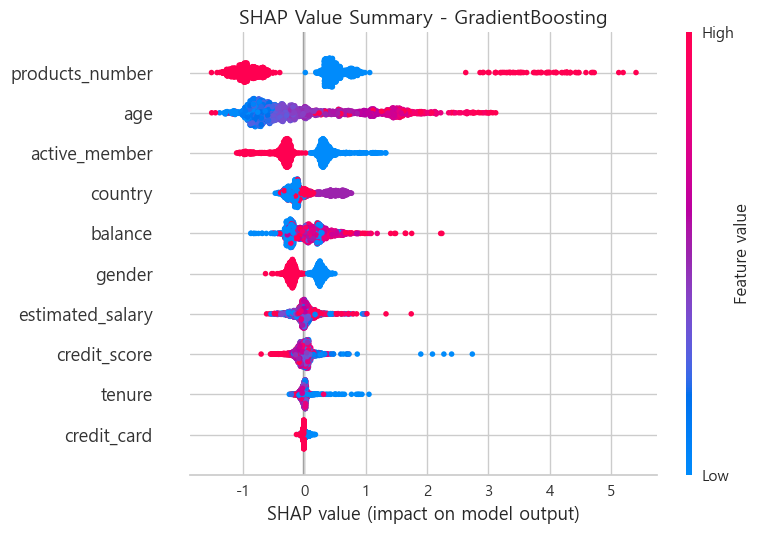

Stacking 최종 성능
accuracy_score: 0.869
F1 score      : 0.601823708206687


In [ ]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# SHAP Value 사후분석
# SHAP 선택 모델: GradientBoosting
# 이유: sklearn 트리 기반 모델로 TreeExplainer가 안정적으로 동작하며 잔차 학습 구조상 각 피처의 기여 방향이 뚜렷하게 나타남

explainer = shap.TreeExplainer(gb)  # GradientBoosting용 TreeExplainer 생성
shap_values = explainer.shap_values(X_valid)  # 검증 데이터의 SHAP value 계산

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 분기 처리 (수업 강조 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # list 형태 → 이탈(1) 클래스의 SHAP 선택
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]  # 3차원 → 이탈 클래스 슬라이싱
else:
    shap_values = shap_values  # 2차원 그대로 사용

# SHAP Summary Plot 시각화
shap.summary_plot(
    shap_values,  # SHAP value 행렬
    X_valid,  # 검증 데이터 피처값
    feature_names=X.columns,  # 피처 이름 레이블
    plot_type="dot",  # 개별 데이터 포인트 시각화 (분포와 방향성 동시 파악)
    show=False,
)
plt.title("SHAP Value Summary - GradientBoosting", fontsize=14)
plt.tight_layout()
plt.show()

# SHAP 해석 및 인사이트
# 1. 보유 상품 수 (Products Number, 중요도 1위)
# 해석: 단순한 선형 관계가 아닌 가장 복잡한 패턴을 보입니다. 상품이 많을수록 전반적인 잔류율은 높으나, 이탈 고객 역시 상당수 존재합니다.
#      이는 실사용 없는 다수 보유나 억지 가입(과잉 판매)으로 인한 불만 누적일 가능성이 큽니다.
# 전략: '다수 보유 = 안전'이라는 가정을 배제해야 합니다.
#      '상품 3개 이상 + 비활성' 고객은 고위험군으로 분류해 즉시 만족도 조사를 시행하고, '1~2개 보유' 고객은 니즈 기반의 정교한 교차 판매로 결속력을 강화해야 합니다.
# 2. 나이 (Age, 중요도 2위)
# 해석: 연령이 높을수록 이탈 확률이 지속해서 상승하는 뚜렷한 단조 증가 관계를 보입니다. 이는 고령층의 디지털 뱅킹 적응 어려움이나 서비스 접근성 부족에서 기인했을 수 있습니다.
# 전략: 50대 이상 시니어 고객을 타겟으로 오프라인 창구 지원 강화, 전담 상담사 배정, 모바일 앱 UI 간소화 등 맞춤형 접근성 개선이 필요합니다.
# 3. 활성 상태 (Active Member, 중요도 3위)
# 해석: 활성 회원은 잔류, 비활성 회원은 이탈하는 명확한 패턴을 보입니다. 활동량 감소는 이탈이 임박했음을 알리는 선행 신호입니다.
# 전략: 비활성 전환 시점의 조기 감지가 핵심입니다. 30/60/90일 미접속 고객을 단계별로 분류해 푸시 알림, 문자, 콜 등 점진적 개입을 시도하고 복귀 인센티브를 제공해야 합니다.

# Stacking 앙상블
# 전방 모델 3개: 부스팅 계열 3가지로 서로 다른 가중치 방식 조합
# → CatBoost(범주형 강점) + XGBoost(정규화 강점) + AdaBoost(약한 분류기 결합)
est_model_list = [
    ("cat", cat),  # CatBoost (범주형 처리에 강한 부스팅)
    ("xgb", xgb),  # XGBoost (정규화 포함 고성능 부스팅)
    ("ada", ada),  # AdaBoost (오분류 샘플에 집중하는 부스팅)
]

# Stacking: 전방 모델 예측 결과를 새 피처로 삼아 후방 모델이 최종 판단
stack = StackingClassifier(
    estimators=est_model_list,  # 전방 모델 리스트
    final_estimator=LogisticRegression(),  # 후방 모델 (해석 가능한 선형 모델)
)
stack.fit(X_train, y_train)  # 스태킹 모델 학습

pred_stack = stack.predict(X_valid)  # 스태킹 모델로 검증 데이터 예측

# 최종 성능
# 불균형 데이터이므로 핵심 평가는 F1, accuracy는 참고 지표로 함께 제시.
# 스태킹(Stacking) 앙상블 모델의 최종 평가 결과, 정확도(Accuracy) 86.9%, F1-Score 60.2%를 달성했습니다.
# 고객 이탈 데이터 특성상 클래스 불균형이 존재하므로, 다수 클래스(유지)에 편향될 수 있는 정확도보다는 소수 클래스(이탈)의 탐지력을 보여주는 F1-Score를 핵심 지표로 삼았습니다.
# 60.2%의 F1-Score는 모델이 실제 이탈 위험군을 놓치지 않고 균형 있게 예측하고 있음을 증명하며, 실무적인 이탈 방어 전략에 즉시 활용 가능한 유의미한 예측 성능을 확보했다고 평가할 수 있습니다.
print("Stacking 최종 성능")
print("accuracy_score:", accuracy_score(y_valid, pred_stack))  # 전체 정확도 (참고용)
print("F1 score      :", f1_score(y_valid, pred_stack))  # 이탈 예측 균형 지표 (핵심)